In [203]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

X = data
Y = target.reshape((506, 1))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=0)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [204]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [205]:
model = Sequential([ Dense(units=13, activation="sigmoid"),
                   Dense(units=8, activation="sigmoid"),
                   Dense(units=5, activation="sigmoid"),
                   Dense(units=1)
                ])

In [206]:
model.compile(loss="mse", optimizer=SGD(learning_rate=0.001))
h = model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test))

Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 629.0757 - val_loss: 568.3790
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 572.7859 - val_loss: 522.8422
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 552.5859 - val_loss: 479.7687
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 475.9775 - val_loss: 436.3051
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 453.0136 - val_loss: 392.0193
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 397.5943 - val_loss: 348.3920
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 360.0387 - val_loss: 306.9236
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 309.6688 - val_loss: 269.2135
Epoch 9/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 309.1677 - val_loss: 236.4908
Epoch 10/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 230.9389 - val_loss: 208.5305
Epoch 11/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 244.6793 - val_loss: 185.4149
Epoch 12/3

In [207]:
type(h)
summary = {
    k: [float(x) if x != "..." else "..." for x in (v[:3] + ["..."] + v[-3:])]
    for k, v in h.history.items()
}
"3 premières et 3 dernières valeurs :", dict(summary)

('3 premières et 3 dernières valeurs :',
 {'loss': [614.101806640625,
   564.2299194335938,
   519.5122680664062,
   '...',
   16.3247127532959,
   16.21504020690918,
   16.18933868408203],
  'val_loss': [568.3790283203125,
   522.8422241210938,
   479.7687072753906,
   '...',
   27.388370513916016,
   27.369359970092773,
   27.04374122619629]})

In [208]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve")
  plt.legend()
  plt.show()

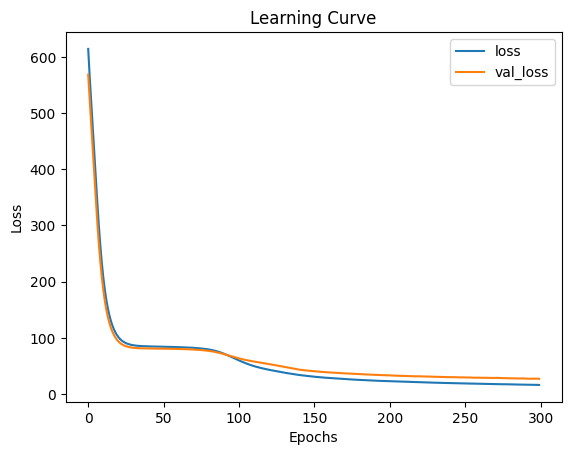

In [209]:
plot_learning_curve(h.history)

In [210]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347 (1.36 KB)

 Trainable params: 345 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [211]:
13*13 + 13

182

In [212]:
13*8 + 8

112

In [213]:
model.save('model.keras')

In [214]:
from tensorflow.keras.models import load_model

In [215]:
new_model = load_model('model.keras')

In [216]:
new_model

<Sequential name=sequential_17, built=True>

In [217]:
new_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347 (1.36 KB)

 Trainable params: 345 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [218]:
P = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [219]:
P.shape

(127, 1)

In [220]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29.6875 


27.04374122619629